In [6]:
import os

INPUT_DIRS = [
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs",
]

In [7]:
for d in INPUT_DIRS:
    print(d, "->", "EXISTS" if os.path.isdir(d) else "MISSING")

/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1 -> EXISTS
/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2 -> EXISTS
/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3 -> EXISTS
/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1 -> EXISTS
/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3 -> EXISTS
/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs -> EXISTS


In [8]:
import time

for d in INPUT_DIRS:
    if not os.path.isdir(d):
        print(f"{d} -> MISSING, skipping")
        continue
    print(f"listing {d} ...")
    t0 = time.time()
    filenames = [f for f in os.listdir(d) if f.endswith(".png")]
    print(f"  -> {len(filenames)} png files found in {time.time() - t0:.1f}s")

listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1 ...
  -> 64000 png files found in 0.0s
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2 ...
  -> 64000 png files found in 0.0s
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3 ...
  -> 64067 png files found in 0.5s
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1 ...
  -> 25000 png files found in 0.0s
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3 ...
  -> 41433 png files found in 0.0s
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs ...
  -> 41500 png files found in 0.0s


In [9]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
MODEL_NAME = "vit_b16"

INPUT_DIRS = [
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs",
]

TRAIN_CSV = ("/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/"
             "rsna-intracranial-hemorrhage-detection/stage_2_train.csv")

MIN_FILE_SIZE_KB = 40
MIN_FILE_SIZE_BYTES = MIN_FILE_SIZE_KB * 1024

LABEL_COLS = ["any", "epidural", "intraparenchymal",
              "intraventricular", "subarachnoid", "subdural"]

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

EARLY_STOPPING_PATIENCE = 5
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
TEST_IDS_PATH = "/kaggle/working/test_ids.csv"

NUM_WORKERS = 4


def load_labels(csv_path):
    y = pd.read_csv(csv_path)
    id_split = y.ID.str.rsplit("_", n=1, expand=True)
    y = pd.concat([id_split, y.Label], axis=1)
    y.columns = ["id", "sub_type", "label"]
    y = y.drop_duplicates(subset=["id", "sub_type"])
    df = y.pivot(index="id", columns="sub_type", values="label")
    return df


class ICHDataset(Dataset):
    def __init__(self, df, id_to_path, transform=None):
        self.df = df
        self.id_to_path = id_to_path
        self.transform = transform
        self.ids = df.index.values
        self.labels = df[LABEL_COLS].values.astype(np.float32)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        path = self.id_to_path[img_id]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


class BalancedRandomSampler(Sampler):
    def __init__(self, labels_any):
        self.pos_idx = np.where(labels_any == 1)[0]
        self.neg_idx = np.where(labels_any == 0)[0]

    def __iter__(self):
        n = min(len(self.neg_idx), max(len(self.pos_idx), 1))
        neg_sample = np.random.choice(self.neg_idx, n, replace=False)
        pos_sample = (np.random.choice(self.pos_idx, n, replace=False)
                      if len(self.pos_idx) > 0 else np.array([], dtype=int))
        ids = np.concatenate([pos_sample, neg_sample])
        np.random.shuffle(ids)
        return iter(ids.tolist())

    def __len__(self):
        return min(len(self.neg_idx), max(len(self.pos_idx), 1)) * 2


def build_resnet50(num_classes=len(LABEL_COLS)):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model.to(DEVICE)


def build_vit_b16(num_classes=len(LABEL_COLS)):
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True
    model.heads = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.hidden_dim, num_classes),
    )
    for param in model.heads.parameters():
        param.requires_grad = True
    return model.to(DEVICE)


MODEL_BUILDERS = {"resnet50": build_resnet50, "vit_b16": build_vit_b16}

OPTIMIZER_CONFIG = {
    "resnet50": {"type": "sgd", "lr": 1e-3, "momentum": 0.9},
    "vit_b16": {"type": "adamw", "lr": 1e-4, "weight_decay": 1e-4},
}

SCHEDULER_CONFIG = {
    "resnet50": {"warmup_epochs": 0},
    "vit_b16": {"warmup_epochs": 1},
}


def build_optimizer(model, model_name):
    cfg = OPTIMIZER_CONFIG[model_name]
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if cfg["type"] == "sgd":
        return torch.optim.SGD(trainable_params, lr=cfg["lr"], momentum=cfg["momentum"])
    elif cfg["type"] == "adamw":
        return torch.optim.AdamW(trainable_params, lr=cfg["lr"],
                                  weight_decay=cfg.get("weight_decay", 0.0))
    else:
        raise ValueError(f"Unknown optimizer type: {cfg['type']}")


def build_scheduler(optimizer, model_name, num_epochs):
    warmup_epochs = SCHEDULER_CONFIG[model_name]["warmup_epochs"]
    warmup_epochs = min(warmup_epochs, max(num_epochs - 1, 0))

    if warmup_epochs > 0:
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(num_epochs - warmup_epochs, 1)
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    return scheduler


def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch, num_epochs):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"train epoch {epoch+1}/{num_epochs}", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, epoch, num_epochs):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc=f"val epoch {epoch+1}/{num_epochs}", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        all_preds.append(torch.sigmoid(outputs.float()).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    aucs = {}
    for i, name in enumerate(LABEL_COLS):
        if len(np.unique(all_labels[:, i])) > 1:
            aucs[name] = roc_auc_score(all_labels[:, i], all_preds[:, i])
        else:
            aucs[name] = float("nan")

    return total_loss / len(loader.dataset), aucs


def run_training(model_name, train_ds, val_ds, y_train):
    print(f"\n{'='*60}")
    print(f"FULL TRAINING RUN: {model_name}")
    print(f"{'='*60}")

    model = MODEL_BUILDERS[model_name]()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = build_optimizer(model, model_name)
    scheduler = build_scheduler(optimizer, model_name, NUM_EPOCHS)
    scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_AMP)

    sampler = BalancedRandomSampler(y_train["any"].values)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.pt")

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        current_lr = optimizer.param_groups[0]["lr"]

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                      scaler, epoch, NUM_EPOCHS)
        val_loss, val_aucs = evaluate(model, val_loader, criterion, epoch, NUM_EPOCHS)

        auc_str = ", ".join(f"{k}={v:.3f}" for k, v in val_aucs.items())
        print(f"[{model_name}] Epoch {epoch+1}/{NUM_EPOCHS} | lr={current_lr:.2e} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {auc_str}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                "model_name": model_name,
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_aucs": val_aucs,
            }, checkpoint_path)
            print(f"[{model_name}]   -> val loss improved, checkpoint saved to {checkpoint_path}")
        else:
            epochs_no_improve += 1
            print(f"[{model_name}]   -> no improvement ({epochs_no_improve}/{EARLY_STOPPING_PATIENCE})")

        scheduler.step()

        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"[{model_name}] Early stopping triggered at epoch {epoch+1}.")
            break

    print(f"[{model_name}] Training complete. Best val_loss={best_val_loss:.4f}, "
          f"checkpoint at {checkpoint_path}")


def scan_input_dirs(input_dirs, min_size_bytes):
    id_to_path = {}
    skipped_small = 0
    for d in input_dirs:
        if not os.path.isdir(d):
            print(f"WARNING: directory not found, skipping: {d}")
            continue
        print(f"listing {d} ...", flush=True)
        filenames = [f for f in os.listdir(d) if f.endswith(".png")]
        print(f"  -> {len(filenames)} png files, scanning sizes...", flush=True)
        for f in tqdm(filenames, desc=f"scanning {os.path.basename(d)}"):
            full_path = os.path.join(d, f)
            if os.path.getsize(full_path) <= min_size_bytes:
                skipped_small += 1
                continue
            img_id = f[:-4]
            id_to_path[img_id] = full_path
    print(f"Scanned {len(input_dirs)} directories: {len(id_to_path)} usable PNGs "
          f"found, {skipped_small} filtered out as low-information (<= "
          f"{min_size_bytes} bytes / {MIN_FILE_SIZE_KB}KB).")
    return id_to_path


def make_splits(df):
    train_df, temp_df = train_test_split(
        df, test_size=VAL_SPLIT + TEST_SPLIT, stratify=df["any"], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
        stratify=temp_df["any"], random_state=42
    )
    return train_df, val_df, test_df


def main():
    print(f"*** FULL TRAINING RUN: {MODEL_NAME} ***")
    print(f"Using device: {DEVICE} | AMP enabled: {USE_AMP}")

    id_to_path = scan_input_dirs(INPUT_DIRS, MIN_FILE_SIZE_BYTES)

    if len(id_to_path) == 0:
        print("\nNo usable PNGs found across INPUT_DIRS. Check the paths are "
              "correct and the datasets are actually attached as Input.")
        return

    df = load_labels(TRAIN_CSV)
    df = df[df.index.isin(id_to_path.keys())]
    print(f"Matched {len(df)} of those to labels. "
          f"Positive rate: {df['any'].mean():.4f}")

    train_df, val_df, test_df = make_splits(df)
    print(f"Full run sizes — train: {len(train_df)}, val: {len(val_df)}, "
          f"test: {len(test_df)}")

    os.makedirs(os.path.dirname(TEST_IDS_PATH), exist_ok=True)
    test_df.index.to_series(name="id").to_csv(TEST_IDS_PATH, index=False)
    print(f"Saved test set ids to {TEST_IDS_PATH}")

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])

    global train_df_g, val_df_g, test_df_g, id_to_path_g
    train_df_g, val_df_g, test_df_g, id_to_path_g = train_df, val_df, test_df, id_to_path

    train_ds = ICHDataset(train_df, id_to_path, transform=train_transform)
    val_ds = ICHDataset(val_df, id_to_path, transform=eval_transform)

    global val_ds_g
    val_ds_g = val_ds

    run_training(MODEL_NAME, train_ds, val_ds, train_df)


main()

*** FULL TRAINING RUN: vit_b16 ***
Using device: cuda | AMP enabled: True
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1 ...
  -> 64000 png files, scanning sizes...


scanning rsna-ich-preprocessed-negative-part1:   0%|          | 0/64000 [00:00<?, ?it/s]

listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2 ...
  -> 64000 png files, scanning sizes...


scanning rsna-ich-preprocessed-negative-part2:   0%|          | 0/64000 [00:00<?, ?it/s]

listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3 ...
  -> 64067 png files, scanning sizes...


...

Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7cf02788c900>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()    Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7cf02788c900>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    Exception ignored in: Traceback (most recent call last):
if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7cf02788c900>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__


     Traceback (most recent call last):
 self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

       File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
 sel

[vit_b16] Epoch 9/15 | lr=5.00e-05 | train_loss=0.0583 | val_loss=0.2164 | any=0.954, epidural=0.930, intraparenchymal=0.948, intraventricular=0.964, subarachnoid=0.909, subdural=0.935
[vit_b16]   -> no improvement (4/5)


train epoch 10/15:   0%|          | 0/4697 [00:00<?, ?it/s]

val epoch 10/15:   0%|          | 0/1262 [00:00<?, ?it/s]

[vit_b16] Epoch 10/15 | lr=3.89e-05 | train_loss=0.0414 | val_loss=0.2411 | any=0.951, epidural=0.921, intraparenchymal=0.944, intraventricular=0.963, subarachnoid=0.908, subdural=0.934
[vit_b16]   -> no improvement (5/5)
[vit_b16] Early stopping triggered at epoch 10.
[vit_b16] Training complete. Best val_loss=0.1726, checkpoint at /kaggle/working/checkpoints/vit_b16_best.pt


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, f1_score,
)
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# CONFIG (same as training run)
# ------------------------------------------------------------------
MODEL_NAME = "vit_b16"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"Using device: {DEVICE}")

INPUT_DIRS = [
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs",
]
TRAIN_CSV = ("/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/"
             "rsna-intracranial-hemorrhage-detection/stage_2_train.csv")
MIN_FILE_SIZE_KB = 40
MIN_FILE_SIZE_BYTES = MIN_FILE_SIZE_KB * 1024
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
LABEL_COLS = ["any", "epidural", "intraparenchymal",
              "intraventricular", "subarachnoid", "subdural"]
CHECKPOINT_PATH = f"/kaggle/working/checkpoints/{MODEL_NAME}_best.pt"


class ICHDataset(Dataset):
    def __init__(self, df, id_to_path, transform=None):
        self.df = df
        self.id_to_path = id_to_path
        self.transform = transform
        self.ids = df.index.values
        self.labels = df[LABEL_COLS].values.astype(np.float32)

    def __len__(self):
        return len(self.ids)

Using device: cuda


In [4]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, f1_score,
)
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# CONFIG (same as training run)
# ------------------------------------------------------------------
MODEL_NAME = "vit_b16"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"Using device: {DEVICE}")

INPUT_DIRS = [
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs",
]
TRAIN_CSV = ("/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/"
             "rsna-intracranial-hemorrhage-detection/stage_2_train.csv")
MIN_FILE_SIZE_KB = 40
MIN_FILE_SIZE_BYTES = MIN_FILE_SIZE_KB * 1024
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
LABEL_COLS = ["any", "epidural", "intraparenchymal",
              "intraventricular", "subarachnoid", "subdural"]
CHECKPOINT_PATH = f"/kaggle/working/checkpoints/{MODEL_NAME}_best.pt"


class ICHDataset(Dataset):
    def __init__(self, df, id_to_path, transform=None):
        self.df = df
        self.id_to_path = id_to_path
        self.transform = transform
        self.ids = df.index.values
        self.labels = df[LABEL_COLS].values.astype(np.float32)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        path = self.id_to_path[img_id]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


def build_resnet50(num_classes=len(LABEL_COLS)):
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, num_classes))
    return model.to(DEVICE)


def build_vit_b16(num_classes=len(LABEL_COLS)):
    model = models.vit_b_16(weights=None)
    model.heads = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.hidden_dim, num_classes))
    return model.to(DEVICE)


MODEL_BUILDERS = {"resnet50": build_resnet50, "vit_b16": build_vit_b16}


def load_labels(csv_path):
    y = pd.read_csv(csv_path)
    id_split = y.ID.str.rsplit("_", n=1, expand=True)
    y = pd.concat([id_split, y.Label], axis=1)
    y.columns = ["id", "sub_type", "label"]
    y = y.drop_duplicates(subset=["id", "sub_type"])
    return y.pivot(index="id", columns="sub_type", values="label")


def scan_input_dirs(input_dirs, min_size_bytes):
    id_to_path = {}
    skipped_small = 0
    for d in input_dirs:
        if not os.path.isdir(d):
            print(f"WARNING: directory not found, skipping: {d}")
            continue
        filenames = [f for f in os.listdir(d) if f.endswith(".png")]
        for f in tqdm(filenames, desc=f"scanning {os.path.basename(d)}"):
            full_path = os.path.join(d, f)
            if os.path.getsize(full_path) <= min_size_bytes:
                skipped_small += 1
                continue
            id_to_path[f[:-4]] = full_path
    print(f"Scanned {len(input_dirs)} directories: {len(id_to_path)} usable PNGs "
          f"found, {skipped_small} filtered out.")
    return id_to_path


def make_splits(df):
    train_df, temp_df = train_test_split(
        df, test_size=VAL_SPLIT + TEST_SPLIT, stratify=df["any"], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
        stratify=temp_df["any"], random_state=42
    )
    return train_df, val_df, test_df


# ------------------------------------------------------------------
# REBUILD: data + model
# ------------------------------------------------------------------
print("Scanning input directories...")
id_to_path = scan_input_dirs(INPUT_DIRS, MIN_FILE_SIZE_BYTES)
df = load_labels(TRAIN_CSV)
df = df[df.index.isin(id_to_path.keys())]
train_df, val_df, test_df = make_splits(df)
print(f"Rebuilt splits — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

os.makedirs("/kaggle/working", exist_ok=True)
test_df.index.to_series(name="id").to_csv("/kaggle/working/test_ids.csv", index=False)

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_ds = ICHDataset(val_df, id_to_path, transform=eval_transform)
test_ds = ICHDataset(test_df, id_to_path, transform=eval_transform)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

model = MODEL_BUILDERS[MODEL_NAME]()
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded checkpoint: epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.4f}")


# ------------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------------
@torch.no_grad()
def run_inference(loader, desc="inference"):
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc=desc):
        imgs = imgs.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
        probs = torch.sigmoid(outputs.float()).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


val_probs, val_labels = run_inference(val_loader, desc="val inference")
test_probs, test_labels = run_inference(test_loader, desc="test inference")
print(f"Done: {len(val_probs)} val images, {len(test_probs)} test images.")

np.savez("/kaggle/working/test_inference_cache.npz",
         val_probs=val_probs, val_labels=val_labels,
         test_probs=test_probs, test_labels=test_labels)
print("Cached val/test probs+labels to /kaggle/working/test_inference_cache.npz")


# ------------------------------------------------------------------
# METRICS TABLE
# ------------------------------------------------------------------
def best_f1_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.nanargmax(f1s[:-1])
    return thresholds[best_idx] if len(thresholds) > 0 else 0.5


rows = []
confusion_matrices = {}

for i, name in enumerate(LABEL_COLS):
    y_true_val = val_labels[:, i]
    y_true_test = test_labels[:, i]
    y_prob_test = test_probs[:, i]

    if len(np.unique(y_true_val)) < 2 or len(np.unique(y_true_test)) < 2:
        continue

    thresh = best_f1_threshold(y_true_val, val_probs[:, i])
    y_pred_test = (y_prob_test >= thresh).astype(int)

    roc_auc = roc_auc_score(y_true_test, y_prob_test)
    pr_auc = average_precision_score(y_true_test, y_prob_test)

    tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true_test, y_pred_test, zero_division=0)

    confusion_matrices[name] = np.array([[tn, fp], [fn, tp]])

    rows.append({
        "class": name, "roc_auc": roc_auc, "pr_auc": pr_auc,
        "threshold_from_val": thresh, "precision": precision,
        "recall_sensitivity": recall, "specificity": specificity, "f1": f1,
        "n_positive": int(y_true_test.sum()), "n_total": len(y_true_test),
    })

results_df = pd.DataFrame(rows).set_index("class")
macro_auc = roc_auc_score(test_labels, test_probs, average="macro")
micro_auc = roc_auc_score(test_labels, test_probs, average="micro")

print("\n" + "=" * 90)
print(f"PER-CLASS METRICS (test split) — {MODEL_NAME}, checkpoint epoch {checkpoint['epoch']}")
print("=" * 90)
print(results_df.round(4).to_string())
print(f"\nMacro-average ROC-AUC: {macro_auc:.4f}")
print(f"Micro-average ROC-AUC: {micro_auc:.4f}")

out_path = f"/kaggle/working/{MODEL_NAME}_eval_metrics.csv"
results_df.to_csv(out_path)
print(f"\nFull metrics table saved to {out_path}")

Using device: cuda
Scanning input directories...


scanning rsna-ich-preprocessed-negative-part1:   0%|          | 0/64000 [00:00<?, ?it/s]

scanning rsna-ich-preprocessed-negative-part2:   0%|          | 0/64000 [00:00<?, ?it/s]

scanning rsna-ich-preprocessed-negative-part3:   0%|          | 0/64067 [00:00<?, ?it/s]

scanning rsna-ich-preprocessed-pngs-positive-part-1:   0%|          | 0/25000 [00:00<?, ?it/s]

...

scanning rsna-ich-preprocessed-pngs:   0%|          | 0/41500 [00:00<?, ?it/s]

Scanned 6 directories: 269147 usable PNGs found, 30853 filtered out.
Rebuilt splits — train: 188402, val: 40372, test: 40373
Loaded checkpoint: epoch 5, val_loss=0.1726


val inference:   0%|          | 0/1262 [00:00<?, ?it/s]

test inference:   0%|          | 0/1262 [00:00<?, ?it/s]

Done: 40372 val images, 40373 test images.
Cached val/test probs+labels to /kaggle/working/test_inference_cache.npz

PER-CLASS METRICS (test split) — vit_b16, checkpoint epoch 5
                  roc_auc  pr_auc  threshold_from_val  precision  recall_sensitivity  specificity      f1  n_positive  n_total
class                                                                                                                         
any                0.9572  0.9451              0.4586     0.8691              0.8655       0.9135  0.8673       16104    40373
epidural           0.9361  0.3970              0.2772     0.3966              0.4340       0.9921  0.4144         477    40373
intraparenchymal   0.9556  0.8481              0.4941     0.8294              0.7015       0.9773  0.7601        5494    40373
intraventricular   0.9687  0.8310              0.2956     0.7539              0.7337       0.9738  0.7437        3980    40373
subarachnoid       0.9165  0.7155              0.3516     0.

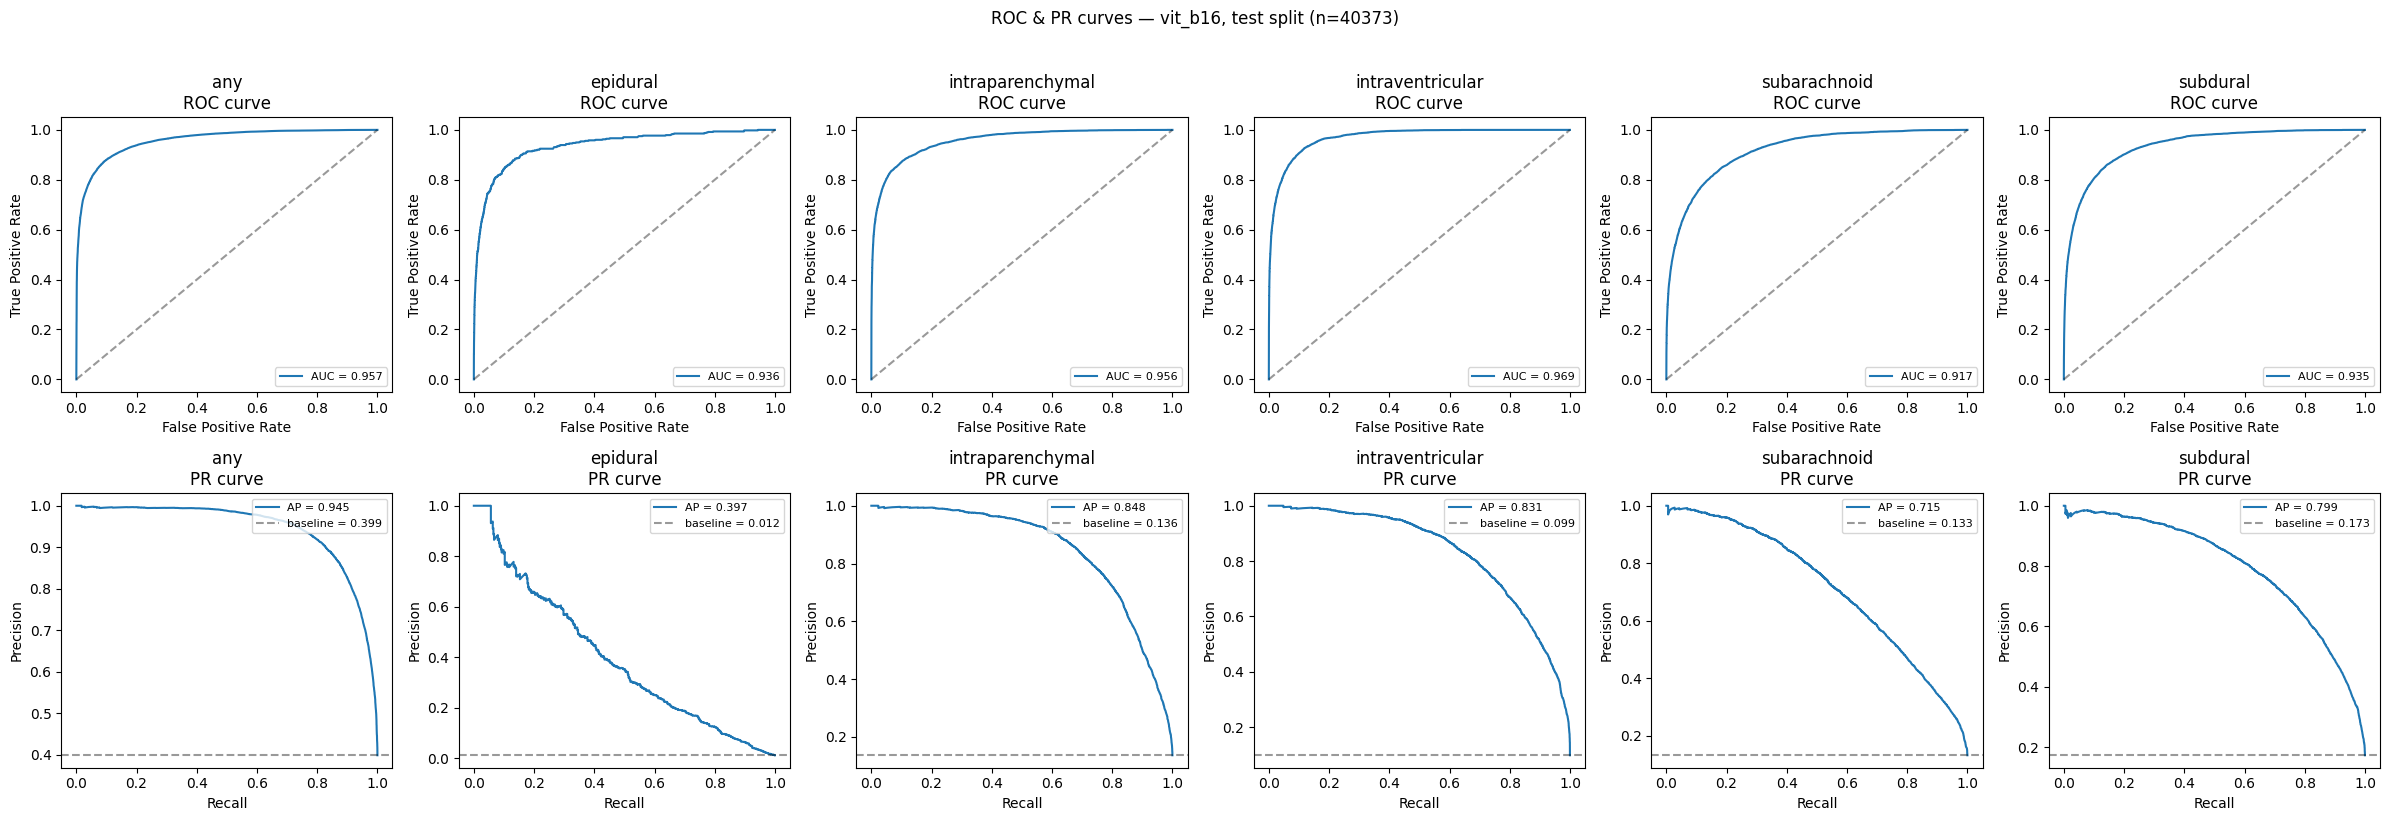

Saved ROC/PR curve grid to /kaggle/working/vit_b16_roc_pr_curves.png


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ------------------------------------------------------------------
# ROC + PR CURVES — per class, test split
# ------------------------------------------------------------------
n_classes = len(LABEL_COLS)
fig, axes = plt.subplots(2, n_classes, figsize=(4 * n_classes, 8))

for i, name in enumerate(LABEL_COLS):
    y_true = test_labels[:, i]
    y_prob = test_probs[:, i]

    if len(np.unique(y_true)) < 2:
        axes[0, i].set_visible(False)
        axes[1, i].set_visible(False)
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax_roc = axes[0, i]
    ax_roc.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.3f}")
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax_roc.set_title(f"{name}\nROC curve")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(fontsize=8, loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = average_precision_score(y_true, y_prob)
    base_rate = y_true.mean()
    ax_pr = axes[1, i]
    ax_pr.plot(recall, precision, label=f"AP = {pr_auc_val:.3f}")
    ax_pr.axhline(base_rate, color="k", linestyle="--", alpha=0.4,
                  label=f"baseline = {base_rate:.3f}")
    ax_pr.set_title(f"{name}\nPR curve")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=8, loc="upper right")

plt.suptitle(f"ROC & PR curves — {MODEL_NAME}, test split (n={len(test_labels)})", y=1.02)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{MODEL_NAME}_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved ROC/PR curve grid to /kaggle/working/{MODEL_NAME}_roc_pr_curves.png")

Running inference (logits) on val split (for fitting T)...
Running inference (logits) on test split (for reporting)...

Fitted temperature: T = 1.1364  (softens the model's confidence)

CALIBRATION METRICS (test split, n=40373) — vit_b16, T=1.1364
                  roc_auc  pr_auc  ece_before  ece_after  mce_before  mce_after  brier_before  brier_after  nll_before  nll_after
class                                                                                                                            
any                0.9572  0.9451      0.0204     0.0109      0.0743     0.0544        0.0772       0.0767      0.2587     0.2548
epidural           0.9361  0.3970      0.0039     0.0078      0.1485     0.1885        0.0090       0.0092      0.0385     0.0401
intraparenchymal   0.9556  0.8481      0.0142     0.0062      0.1001     0.0873        0.0460       0.0457      0.1643     0.1613
intraventricular   0.9687  0.8310      0.0126     0.0076      0.0883     0.0934        0.0361       0.

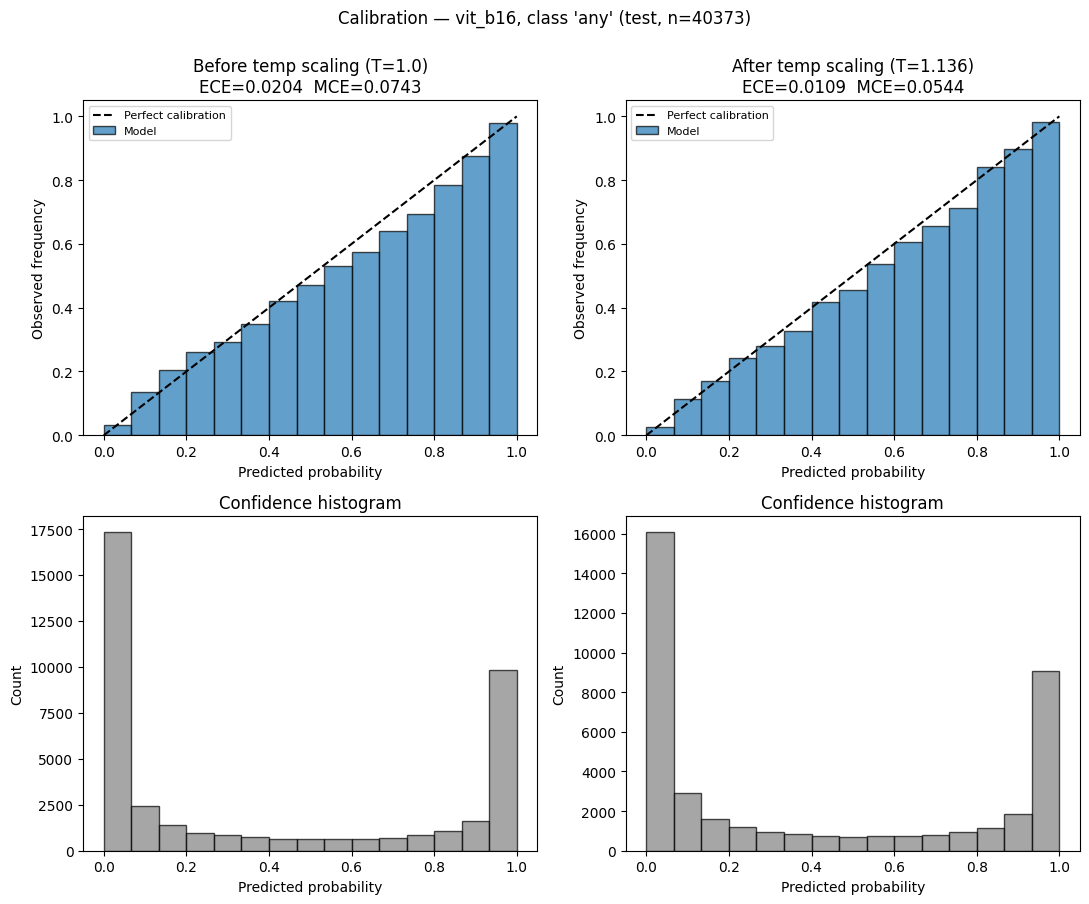


Saved calibration table to /kaggle/working/vit_b16_calibration_metrics.csv
Saved fitted T to /kaggle/working/vit_b16_temperature.txt
Saved reliability diagram to /kaggle/working/vit_b16_calibration_reliability.png


In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

N_BINS = 15


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        return logits / torch.exp(self.log_T)


@torch.no_grad()
def get_logits(loader):
    all_logits, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
        all_logits.append(outputs.float().cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


print("Running inference (logits) on val split (for fitting T)...")
val_logits, val_labels_t = get_logits(val_loader)
print("Running inference (logits) on test split (for reporting)...")
test_logits, test_labels_t = get_logits(test_loader)

scaler = TemperatureScaler()
optimizer = torch.optim.LBFGS([scaler.log_T], lr=0.05, max_iter=100)
bce = nn.BCEWithLogitsLoss()

def closure():
    optimizer.zero_grad()
    loss = bce(scaler(val_logits), val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)
T = torch.exp(scaler.log_T).item()
print(f"\nFitted temperature: T = {T:.4f}  "
      f"({'softens' if T > 1 else 'sharpens'} the model's confidence)")


def expected_and_max_calibration_error(y_true, y_prob, n_bins=15):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    bin_accs, bin_confs, bin_counts = [], [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob > lo) & (y_prob <= hi)
        count = mask.sum()
        if count == 0:
            bin_accs.append(np.nan)
            bin_confs.append((lo + hi) / 2)
            bin_counts.append(0)
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        gap = abs(acc - conf)
        ece += (count / len(y_prob)) * gap
        mce = max(mce, gap)
        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(count)
    return ece, mce, bin_edges, bin_accs, bin_confs, bin_counts


def nll(y_true, y_prob):
    eps = 1e-12
    p = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


test_labels_np = test_labels_t.numpy()
probs_before = torch.sigmoid(test_logits).numpy()
probs_after = torch.sigmoid(test_logits / T).numpy()

rows = []
for i, name in enumerate(LABEL_COLS):
    y_true = test_labels_np[:, i]
    if len(np.unique(y_true)) < 2:
        continue

    p_before, p_after = probs_before[:, i], probs_after[:, i]
    ece_b, mce_b, *_ = expected_and_max_calibration_error(y_true, p_before, N_BINS)
    ece_a, mce_a, *_ = expected_and_max_calibration_error(y_true, p_after, N_BINS)

    rows.append({
        "class": name,
        "roc_auc": roc_auc_score(y_true, p_before),
        "pr_auc": average_precision_score(y_true, p_before),
        "ece_before": ece_b, "ece_after": ece_a,
        "mce_before": mce_b, "mce_after": mce_a,
        "brier_before": brier_score_loss(y_true, p_before),
        "brier_after": brier_score_loss(y_true, p_after),
        "nll_before": nll(y_true, p_before),
        "nll_after": nll(y_true, p_after),
    })

calib_results_df = pd.DataFrame(rows).set_index("class")
print("\n" + "=" * 100)
print(f"CALIBRATION METRICS (test split, n={len(test_labels_np)}) — {MODEL_NAME}, T={T:.4f}")
print("=" * 100)
print(calib_results_df.round(4).to_string())

macro_ece_before = calib_results_df["ece_before"].mean()
macro_ece_after = calib_results_df["ece_after"].mean()
macro_brier_before = calib_results_df["brier_before"].mean()
macro_brier_after = calib_results_df["brier_after"].mean()
print(f"\nMacro-avg ECE:   before={macro_ece_before:.4f} -> after={macro_ece_after:.4f}")
print(f"Macro-avg Brier: before={macro_brier_before:.4f} -> after={macro_brier_after:.4f}")

any_idx = LABEL_COLS.index("any")
y_true_any = test_labels_np[:, any_idx]
p_before_any = probs_before[:, any_idx]
p_after_any = probs_after[:, any_idx]

ece_b, mce_b, edges_b, accs_b, confs_b, counts_b = expected_and_max_calibration_error(
    y_true_any, p_before_any, N_BINS)
ece_a, mce_a, edges_a, accs_a, confs_a, counts_a = expected_and_max_calibration_error(
    y_true_any, p_after_any, N_BINS)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
bin_centers = (edges_b[:-1] + edges_b[1:]) / 2
bin_width = 1 / N_BINS

for col, (accs, counts, ece, mce, label) in enumerate([
    (accs_b, counts_b, ece_b, mce_b, "Before temp scaling (T=1.0)"),
    (accs_a, counts_a, ece_a, mce_a, f"After temp scaling (T={T:.3f})"),
]):
    valid = [not np.isnan(a) for a in accs]
    ax_rel = axes[0, col]
    ax_rel.bar(np.array(bin_centers)[valid], np.array(accs)[valid],
               width=bin_width, edgecolor="black", alpha=0.7, label="Model")
    ax_rel.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax_rel.set_xlabel("Predicted probability")
    ax_rel.set_ylabel("Observed frequency")
    ax_rel.set_title(f"{label}\nECE={ece:.4f}  MCE={mce:.4f}")
    ax_rel.legend(fontsize=8)

    ax_hist = axes[1, col]
    ax_hist.bar(bin_centers, counts, width=bin_width, edgecolor="black", alpha=0.7, color="gray")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title("Confidence histogram")

plt.suptitle(f"Calibration — {MODEL_NAME}, class 'any' (test, n={len(test_labels_np)})", y=1.00)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{MODEL_NAME}_calibration_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

out_path = f"/kaggle/working/{MODEL_NAME}_calibration_metrics.csv"
calib_results_df.to_csv(out_path)
with open(f"/kaggle/working/{MODEL_NAME}_temperature.txt", "w") as f:
    f.write(f"T={T:.6f}\n")
print(f"\nSaved calibration table to {out_path}")
print(f"Saved fitted T to /kaggle/working/{MODEL_NAME}_temperature.txt")
print(f"Saved reliability diagram to /kaggle/working/{MODEL_NAME}_calibration_reliability.png")

[any] computing CAMs for 30 images (13938 available)...


any:   0%|          | 0/30 [00:00<?, ?it/s]

[epidural] computing CAMs for 30 images (207 available)...


epidural:   0%|          | 0/30 [00:00<?, ?it/s]

[intraparenchymal] computing CAMs for 30 images (3854 available)...


...

intraventricular:   0%|          | 0/30 [00:00<?, ?it/s]

[subarachnoid] computing CAMs for 30 images (3403 available)...


subarachnoid:   0%|          | 0/30 [00:00<?, ?it/s]

[subdural] computing CAMs for 30 images (5156 available)...


subdural:   0%|          | 0/30 [00:00<?, ?it/s]

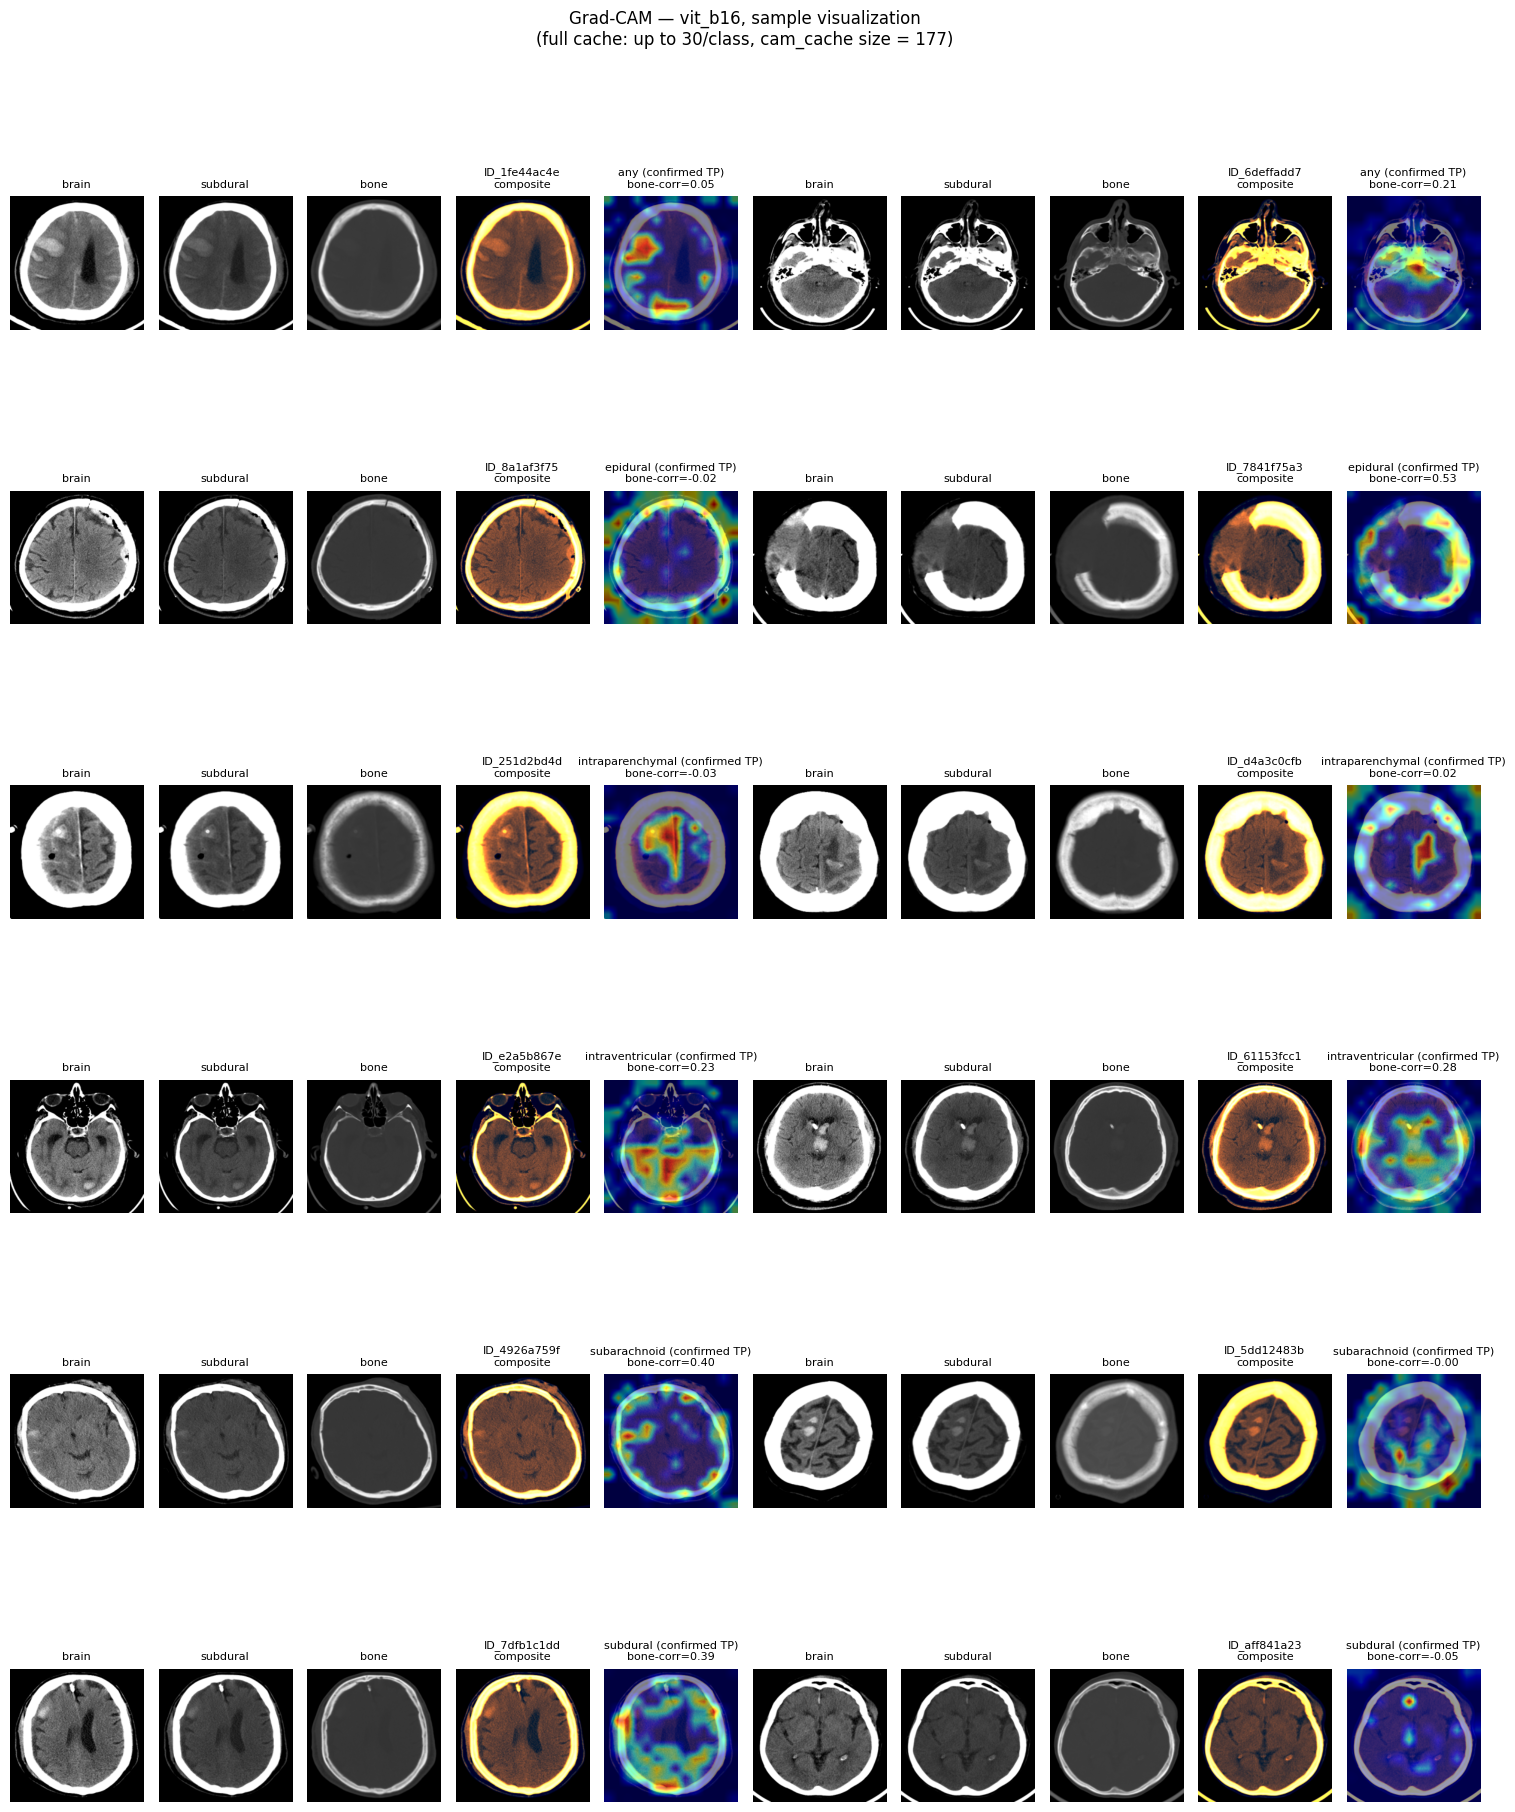


Sample sizes used per class:
           class  n_available  n_sampled
             any        13938         30
        epidural          207         30
intraparenchymal         3854         30
intraventricular         2920         30
    subarachnoid         3403         30
        subdural         5156         30

Saved cam_cache + img_cache (177 images) to /kaggle/working/cam_cache.pkl

BONE-CHANNEL SHORTCUT CHECK (full sampled set)
                   mean    std  count
class                                
any              -0.049  0.251     30
epidural         -0.014  0.274     30
intraparenchymal -0.011  0.115     30
intraventricular  0.174  0.174     30
subarachnoid      0.031  0.193     30
subdural          0.056  0.210     30

Saved per-example bone-correlation records to /kaggle/working/vit_b16_bone_shortcut_correlations.csv


In [10]:
!pip install grad-cam -q

import os
import json
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------------------------------------------------------------
# GRAD-CAM (ViT) — scaled up sample, for stable AOPC/Max-Sensitivity input.
# Computes+caches CAMs for N_CAM_SAMPLES confirmed TPs per class,
# but only visualizes a small subset (grid would be unusable at N=30).
# ------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_CAM_SAMPLES = 30          # per class, capped by availability (esp. epidural)
N_VISUALIZE_PER_CLASS = 2   # kept small — just a sanity-check grid

GRADCAM_OUT_DIR = "/kaggle/working/gradcam_examples"
CAM_CACHE_PATH = "/kaggle/working/cam_cache.pkl"
os.makedirs(GRADCAM_OUT_DIR, exist_ok=True)

CHANNEL_NAMES = ["brain", "subdural", "bone"]

# --- ViT-specific: reshape the 196 patch tokens back into a 14x14 grid ---
# 224px image / 16px patch = 14 patches per side -> 14*14 = 196 tokens,
# plus 1 CLS token at index 0 which we drop before reshaping.
def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # bring channels to dim 1, like a conv activation: [B, C, H, W]
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layers = [model.encoder.layers[-1].ln_1]
cam = GradCAM(model=model, target_layers=target_layers,
              reshape_transform=vit_reshape_transform)

cam_cache = {}          # img_id -> {class_name: grayscale_cam}
img_cache = {}          # img_id -> img_np (3-window array), reused by AOPC/Max-Sensitivity
bone_corr_records = []


def load_image_for_cam(path):
    img = Image.open(path).convert("RGB").resize((224, 224))
    img_np = np.array(img).astype(np.float32) / 255.0
    input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    return input_tensor, img_np


def bone_shortcut_correlation(grayscale_cam, bone_channel):
    cam_flat = grayscale_cam.flatten()
    bone_flat = bone_channel.flatten()
    if cam_flat.std() < 1e-8 or bone_flat.std() < 1e-8:
        return np.nan
    return float(np.corrcoef(cam_flat, bone_flat)[0, 1])


def compute_gradcam(img_id, class_idx, class_name, id_to_path):
    path = id_to_path[img_id]
    input_tensor, img_np = load_image_for_cam(path)
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    cam_cache.setdefault(img_id, {})[class_name] = grayscale_cam
    img_cache[img_id] = img_np

    bone_channel = img_np[:, :, 2]
    corr = bone_shortcut_correlation(grayscale_cam, bone_channel)
    bone_corr_records.append({"img_id": img_id, "class": class_name, "bone_corr": corr})

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return img_np, visualization, grayscale_cam, corr


def show_and_save_gradcam_panel(img_id, class_idx, class_name, id_to_path, fig_axes, tag=""):
    img_np, visualization, grayscale_cam, corr = compute_gradcam(
        img_id, class_idx, class_name, id_to_path
    )
    ax_brain, ax_subdural, ax_bone, ax_composite, ax_cam = fig_axes

    ax_brain.imshow(img_np[:, :, 0], cmap="gray"); ax_brain.set_title("brain", fontsize=8); ax_brain.axis("off")
    ax_subdural.imshow(img_np[:, :, 1], cmap="gray"); ax_subdural.set_title("subdural", fontsize=8); ax_subdural.axis("off")
    ax_bone.imshow(img_np[:, :, 2], cmap="gray"); ax_bone.set_title("bone", fontsize=8); ax_bone.axis("off")
    ax_composite.imshow(img_np); ax_composite.set_title(f"{img_id}\ncomposite", fontsize=8); ax_composite.axis("off")
    ax_cam.imshow(visualization); ax_cam.set_title(f"{class_name}{tag}\nbone-corr={corr:.2f}", fontsize=8); ax_cam.axis("off")

    out_path = os.path.join(GRADCAM_OUT_DIR, f"{class_name}_{img_id}{tag.replace(' ', '_')}.png")
    Image.fromarray(visualization).save(out_path)


# ------------------------------------------------------------------
# Per-class predictions using val-derived thresholds
# ------------------------------------------------------------------
test_ids_array = test_df.index.values
class_preds = {}
for class_name in results_df.index:
    class_idx = LABEL_COLS.index(class_name)
    thresh = results_df.loc[class_name, "threshold_from_val"]
    class_preds[class_name] = (test_probs[:, class_idx] >= thresh)

# ------------------------------------------------------------------
# Compute + cache CAMs for N_CAM_SAMPLES confirmed TPs per class.
# Only the first N_VISUALIZE_PER_CLASS of each are plotted.
# ------------------------------------------------------------------
classes_to_show = ["any", "epidural", "intraparenchymal",
                    "intraventricular", "subarachnoid", "subdural"]

n_cols = N_VISUALIZE_PER_CLASS * 5
fig, axes = plt.subplots(len(classes_to_show), n_cols,
                          figsize=(3 * n_cols / 2, 3.2 * len(classes_to_show)))

sample_summary = []

for row, class_name in enumerate(classes_to_show):
    class_idx = LABEL_COLS.index(class_name)
    y_true = test_labels[:, class_idx]
    y_pred = class_preds[class_name]

    true_pos_mask = (y_true == 1) & (y_pred == 1)
    true_pos_ids = test_ids_array[true_pos_mask]
    true_pos_ids = np.array([i for i in true_pos_ids if i in id_to_path])

    n_available = len(true_pos_ids)
    n_sample = min(N_CAM_SAMPLES, n_available)
    sample_summary.append({"class": class_name, "n_available": n_available, "n_sampled": n_sample})

    if n_sample == 0:
        for col in range(n_cols):
            axes[row, col].set_visible(False)
        print(f"WARNING: no confirmed true positives with resolvable paths for '{class_name}'.")
        continue

    sample_ids = np.random.choice(true_pos_ids, size=n_sample, replace=False)

    print(f"[{class_name}] computing CAMs for {n_sample} images "
          f"({n_available} available)...")
    for i, img_id in enumerate(tqdm(sample_ids, desc=class_name, leave=False)):
        if i < N_VISUALIZE_PER_CLASS:
            panel_axes = axes[row, i * 5:(i + 1) * 5]
            show_and_save_gradcam_panel(img_id, class_idx, class_name, id_to_path,
                                         panel_axes, tag=" (confirmed TP)")
        else:
            compute_gradcam(img_id, class_idx, class_name, id_to_path)

    for col in range(min(N_VISUALIZE_PER_CLASS, n_sample) * 5, n_cols):
        axes[row, col].set_visible(False)

plt.suptitle(f"Grad-CAM — {MODEL_NAME}, sample visualization\n"
             f"(full cache: up to {N_CAM_SAMPLES}/class, cam_cache size = {len(cam_cache)})",
             y=1.001)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{MODEL_NAME}_gradcam_sample_visualization.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"\nSample sizes used per class:")
print(pd.DataFrame(sample_summary).to_string(index=False))

with open(CAM_CACHE_PATH, "wb") as f:
    pickle.dump({"cam_cache": cam_cache, "img_cache": img_cache}, f)
print(f"\nSaved cam_cache + img_cache ({len(cam_cache)} images) to {CAM_CACHE_PATH}")

bone_corr_df = pd.DataFrame(bone_corr_records)
print("\n" + "=" * 70)
print("BONE-CHANNEL SHORTCUT CHECK (full sampled set)")
print("=" * 70)
print(bone_corr_df.groupby("class")["bone_corr"].agg(["mean", "std", "count"]).round(3))

bone_corr_out = f"/kaggle/working/{MODEL_NAME}_bone_shortcut_correlations.csv"
bone_corr_df.to_csv(bone_corr_out, index=False)
print(f"\nSaved per-example bone-correlation records to {bone_corr_out}")

In [11]:
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# AOPC + MAX-SENSITIVITY — ViT-B/16, Grad-CAM explainability validation
# ------------------------------------------------------------------
# AOPC (Samek et al., 2016): measures whether the CAM correctly
# identifies pixels the model actually relies on. Progressively
# perturbs the highest-ranked CAM regions and measures how fast the
# predicted probability drops. A steep drop = a faithful explanation.
#
# Max-Sensitivity (Yeh et al., 2019): measures explanation robustness.
# Adds small random noise to the input several times and recomputes
# the CAM each time; reports the MAX heatmap change observed. Low
# sensitivity = a robust/trustworthy explanation.
#
# Perturbation baseline: PER-CHANNEL MEAN of the image itself, not
# zero-fill (same rationale as the ResNet run — 0 in a given window
# channel is a specific clinical HU value, not "no information").
# Perturbation operates on a 14x14 patch grid (16px patches), which
# for ViT also happens to match the native patch tokenization — so
# each perturbed patch corresponds to exactly one input token.

N_SAMPLES_PER_CLASS = 50
N_AOPC_STEPS = 10            # cumulative 10%, 20%, ..., 100% of patches perturbed
GRID_SIZE = 16               # kept consistent with the ResNet run for comparability;
                              # NOTE: ViT's native patch grid is 14x14 (16px patches on
                              # a 224px image already == GRID_SIZE here, so this lines
                              # up with the model's own tokenization, not just the CAM).
N_SENSITIVITY_REPEATS = 10
NOISE_STD_FRACTION = 0.05    # noise magnitude as a fraction of per-channel image std

np.random.seed(RANDOM_SEED)
patch_size = 224 // GRID_SIZE


def normalize_np_to_tensor(img_np):
    """img_np: [H,W,3] float in [0,1] -> normalized [1,3,H,W] tensor, matching eval_transform."""
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    normed = (img_np - mean) / std
    tensor = torch.from_numpy(normed.transpose(2, 0, 1)).unsqueeze(0).float().to(DEVICE)
    return tensor


@torch.no_grad()
def get_class_prob(img_np, class_idx):
    input_tensor = normalize_np_to_tensor(img_np)
    with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
        outputs = model(input_tensor)
    return torch.sigmoid(outputs.float())[0, class_idx].item()


def cam_to_patch_ranking(grayscale_cam):
    """Average CAM value per grid patch, return patch indices ranked descending by importance."""
    patch_scores = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            patch = grayscale_cam[i * patch_size:(i + 1) * patch_size,
                                   j * patch_size:(j + 1) * patch_size]
            patch_scores[i, j] = patch.mean()
    flat_order = np.argsort(-patch_scores.flatten())  # descending importance
    return flat_order


def perturb_patches(img_np, patch_indices_to_remove):
    """Replace given patches (flat indices into GRID_SIZE x GRID_SIZE) with per-channel mean-fill."""
    perturbed = img_np.copy()
    channel_means = img_np.reshape(-1, 3).mean(axis=0)  # per-channel mean over whole image
    for flat_idx in patch_indices_to_remove:
        i, j = divmod(flat_idx, GRID_SIZE)
        perturbed[i * patch_size:(i + 1) * patch_size,
                  j * patch_size:(j + 1) * patch_size, :] = channel_means
    return perturbed


def compute_aopc(img_np, grayscale_cam, class_idx):
    ranking = cam_to_patch_ranking(grayscale_cam)
    total_patches = GRID_SIZE * GRID_SIZE
    original_prob = get_class_prob(img_np, class_idx)

    drops = []
    for step in range(1, N_AOPC_STEPS + 1):
        n_remove = int(total_patches * step / N_AOPC_STEPS)
        perturbed_img = perturb_patches(img_np, ranking[:n_remove])
        perturbed_prob = get_class_prob(perturbed_img, class_idx)
        drops.append(original_prob - perturbed_prob)

    return float(np.mean(drops))


def compute_max_sensitivity(img_id, class_idx, class_name, id_to_path):
    """Recomputes the CAM under small random noise perturbations; returns max heatmap change."""
    path = id_to_path[img_id]
    orig_tensor, orig_img_np = load_image_for_cam(path)
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    targets = [ClassifierOutputTarget(class_idx)]

    orig_cam = cam(input_tensor=orig_tensor, targets=targets)[0, :]
    noise_std = NOISE_STD_FRACTION * orig_img_np.std()

    max_diff = 0.0
    for _ in range(N_SENSITIVITY_REPEATS):
        noise = np.random.normal(0, noise_std, orig_img_np.shape).astype(np.float32)
        noisy_img = np.clip(orig_img_np + noise, 0, 1)
        noisy_tensor = normalize_np_to_tensor(noisy_img)
        noisy_cam = cam(input_tensor=noisy_tensor, targets=targets)[0, :]
        diff = np.linalg.norm(orig_cam - noisy_cam)
        max_diff = max(max_diff, diff)

    return float(max_diff)


# ------------------------------------------------------------------
# Run over confirmed true positives per class
# ------------------------------------------------------------------
test_ids_array = test_df.index.values
records = []

for class_name in results_df.index:
    class_idx = LABEL_COLS.index(class_name)
    y_true = test_labels[:, class_idx]
    y_pred = class_preds[class_name]

    true_pos_mask = (y_true == 1) & (y_pred == 1)
    true_pos_ids = test_ids_array[true_pos_mask]
    true_pos_ids = np.array([i for i in true_pos_ids if i in id_to_path])

    n_sample = min(N_SAMPLES_PER_CLASS, len(true_pos_ids))
    if n_sample == 0:
        print(f"Skipping '{class_name}' — no confirmed true positives with resolvable paths.")
        continue

    sample_ids = np.random.choice(true_pos_ids, size=n_sample, replace=False)
    print(f"\n{class_name}: running AOPC + Max-Sensitivity on {n_sample} confirmed TPs "
          f"(available: {len(true_pos_ids)})")

    for img_id in tqdm(sample_ids, desc=class_name):
        path = id_to_path[img_id]
        _, img_np = load_image_for_cam(path)

        if img_id in cam_cache and class_name in cam_cache[img_id]:
            grayscale_cam = cam_cache[img_id][class_name]
        else:
            input_tensor, _ = load_image_for_cam(path)
            from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
            grayscale_cam = cam(input_tensor=input_tensor,
                                 targets=[ClassifierOutputTarget(class_idx)])[0, :]
            cam_cache.setdefault(img_id, {})[class_name] = grayscale_cam

        aopc = compute_aopc(img_np, grayscale_cam, class_idx)
        max_sens = compute_max_sensitivity(img_id, class_idx, class_name, id_to_path)

        records.append({
            "img_id": img_id, "class": class_name,
            "aopc": aopc, "max_sensitivity": max_sens,
        })

aopc_sens_df = pd.DataFrame(records)

print("\n" + "=" * 80)
print("AOPC + MAX-SENSITIVITY SUMMARY (mean ± std, per class)")
print("=" * 80)
summary = aopc_sens_df.groupby("class").agg(
    aopc_mean=("aopc", "mean"), aopc_std=("aopc", "std"),
    sens_mean=("max_sensitivity", "mean"), sens_std=("max_sensitivity", "std"),
    n=("aopc", "count"),
).round(4)
print(summary.to_string())

out_path = f"/kaggle/working/{MODEL_NAME}_aopc_max_sensitivity.csv"
aopc_sens_df.to_csv(out_path, index=False)
summary_out_path = f"/kaggle/working/{MODEL_NAME}_aopc_max_sensitivity_summary.csv"
summary.to_csv(summary_out_path)
print(f"\nSaved per-image results to {out_path}")
print(f"Saved per-class summary to {summary_out_path}")


any: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 13938)


any:   0%|          | 0/50 [00:00<?, ?it/s]


epidural: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 207)


epidural:   0%|          | 0/50 [00:00<?, ?it/s]


intraparenchymal: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 3854)


...


subarachnoid: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 3403)


subarachnoid:   0%|          | 0/50 [00:00<?, ?it/s]


subdural: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 5156)


subdural:   0%|          | 0/50 [00:00<?, ?it/s]


AOPC + MAX-SENSITIVITY SUMMARY (mean ± std, per class)
                  aopc_mean  aopc_std  sens_mean  sens_std   n
class                                                         
any                  0.3859    0.1963    24.1945    7.9772  50
epidural             0.5047    0.2058    29.9434    7.5488  50
intraparenchymal     0.6335    0.2666    23.0017    9.8101  50
intraventricular     0.6942    0.2253    21.9595    7.5424  50
subarachnoid         0.6274    0.2102    21.6558    8.3443  50
subdural             0.5627    0.2085    21.2431    7.2466  50

Saved per-image results to /kaggle/working/vit_b16_aopc_max_sensitivity.csv
Saved per-class summary to /kaggle/working/vit_b16_aopc_max_sensitivity_summary.csv


In [12]:
import shutil
import os
from IPython.display import FileLink

zip_base_name = "/kaggle/working/vit_b16_full_outputs"
output_dir = "/kaggle/working/vit_b16_full_outputs_files"
os.makedirs(output_dir, exist_ok=True)

for f in [
    f"/kaggle/working/checkpoints/{MODEL_NAME}_best.pt",
    f"/kaggle/working/{MODEL_NAME}_eval_metrics.csv",
    f"/kaggle/working/{MODEL_NAME}_roc_pr_curves.png",
    f"/kaggle/working/{MODEL_NAME}_calibration_metrics.csv",
    f"/kaggle/working/{MODEL_NAME}_calibration_reliability.png",
    f"/kaggle/working/{MODEL_NAME}_temperature.txt",
    "/kaggle/working/test_ids.csv",
    "/kaggle/working/test_inference_cache.npz",
    f"/kaggle/working/{MODEL_NAME}_gradcam_sample_visualization.png",
    f"/kaggle/working/{MODEL_NAME}_bone_shortcut_correlations.csv",
    f"/kaggle/working/{MODEL_NAME}_aopc_max_sensitivity.csv",
    f"/kaggle/working/{MODEL_NAME}_aopc_max_sensitivity_summary.csv",
    "/kaggle/working/cam_cache.pkl",
]:
    if os.path.exists(f):
        shutil.copy(f, output_dir)
        print(f"Added: {f}")
    else:
        print(f"Skipped (not found): {f}")

shutil.make_archive(zip_base_name, "zip", output_dir)
print(f"\nBacked up to {zip_base_name}.zip")

FileLink(f"{zip_base_name}.zip")

Added: /kaggle/working/checkpoints/vit_b16_best.pt
Added: /kaggle/working/vit_b16_eval_metrics.csv
Added: /kaggle/working/vit_b16_roc_pr_curves.png
Added: /kaggle/working/vit_b16_calibration_metrics.csv
Added: /kaggle/working/vit_b16_calibration_reliability.png
Added: /kaggle/working/vit_b16_temperature.txt
Added: /kaggle/working/test_ids.csv
Added: /kaggle/working/test_inference_cache.npz
Added: /kaggle/working/vit_b16_gradcam_sample_visualization.png
Added: /kaggle/working/vit_b16_bone_shortcut_correlations.csv
Added: /kaggle/working/vit_b16_aopc_max_sensitivity.csv
Added: /kaggle/working/vit_b16_aopc_max_sensitivity_summary.csv
Added: /kaggle/working/cam_cache.pkl

Backed up to /kaggle/working/vit_b16_full_outputs.zip


/kaggle/working/vit_b16_full_outputs.zip